# Game map viewer

Set `GAME` and `PARAMS` in the **Board** cell, run it, and the map is drawn inline.

`render()` is a method of each game class and returns a `PIL.Image.Image`, so the
notebook shows it as the value of the last expression and saving is the image's
own job:

```python
img = mdp.render()
img.save("board.png")        # .png, .pdf, .jpg — whatever Pillow writes
```

**Reading the picture**

| | meaning |
|---|---|
| black bar *between* two cells | a sealed wall — walls are thin and occupy no cell |
| orange arrow | a one-way door, pointing the only direction traffic may go |
| dark grey cell | obstacle |
| `S` / `G` | start / goal |
| `T` / `P` / `D` | taxi start / passenger / destination *(taxiworld)* |
| `V` / `D` | valuable / dangerous rock *(rockworld)* |
| `~` | puddle *(puddleworld)* |

Rooms are joined only by east- and south-facing doors, so the room grid is a DAG:
going through a door **commits**, and the rooms behind you are gone for good.

In [1]:
from gridworld_core import GridWorld, board_side
from puddleworld import PuddleWorld
from rockworld import RockWorld
from taxiworld import TaxiWorld

GAMES = {"gridworld": GridWorld, "puddleworld": PuddleWorld,
         "rockworld": RockWorld, "taxiworld": TaxiWorld}


def build(game, rooms_per_side=3, room_side=3, **params):
    """One MDP of `game`, with the two corners as start and goal.

    The board is `rooms_per_side * room_side` cells a side — thin walls take up
    no cells — so the goal corner is derived here rather than passed in, and it
    cannot disagree with the board the game builds.  taxiworld calls the same cell
    `destination`, which is the only per-game difference.
    """
    n = board_side(rooms_per_side, room_side)
    corners = (dict(start=(0, 0), destination=(n - 1, n - 1)) if game == "taxiworld"
               else dict(start=(0, 0), goal=(n - 1, n - 1)))
    return GAMES[game](rooms_per_side=rooms_per_side, room_side=room_side,
                       **corners, **params)

## Board — edit this cell

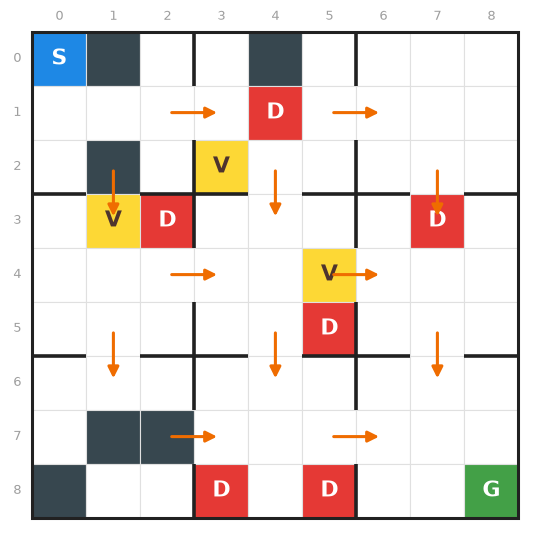

In [2]:
GAME = "rockworld"          # gridworld | puddleworld | rockworld | taxiworld

PARAMS = dict(
    rooms_per_side=3,       # rooms along each side of the board
    room_side=3,            # cells along each side of one room
    obstacle_density=0.08,
    obstacle_seed=11,       # change this to redraw: doors and obstacles both move

    rock_density=0.12,      # rockworld only
    # puddle_density=0.18,  # puddleworld only
)

mdp = build(GAME, **PARAMS)

r, c = PARAMS["rooms_per_side"], PARAMS["room_side"]
img = mdp.render(title=f"{GAME} — {r}x{r} rooms of {c}x{c}, board {mdp.board_side}x{mdp.board_side}")
img

## Save it

In [3]:
img.save("board.png")
print("wrote board.png", img.size)

wrote board.png (550, 550)


## The same board as ASCII

`visualize()` is the print form of the same thing — handy in a terminal, but it can
only hint at thin walls (`|` and `-` are sealed, `>` and `v` are doors).

In [4]:
mdp.visualize()

S # .|. # .|. . .
. . .>. D .>. . .
. # .|V . .|. . .
- v - - v - - v -
. V D|. . .|. D .
. . .>. . V>. . .
. . .|. . D|. . .
- v - - v - - v -
. . .|. . .|. . .
. # #>. . .>. . .
# . .|D . D|. . G


## All four games on one sheet

Same seed and same walls for each, so only the game-specific contents differ.

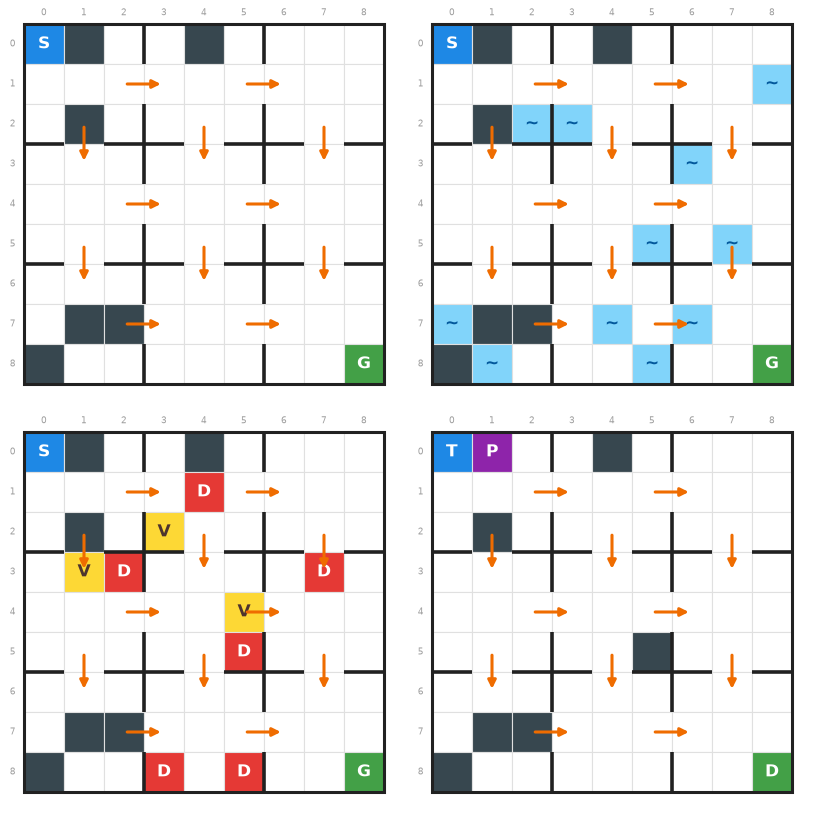

In [5]:
from PIL import Image

shots = {g: build(g, obstacle_density=0.08, obstacle_seed=11,
                  **({"rock_density": 0.12} if g == "rockworld" else
                     {"puddle_density": 0.18} if g == "puddleworld" else {})
                  ).render(cell_px=40, title=g)
         for g in GAMES}

w, h = next(iter(shots.values())).size
sheet = Image.new("RGBA", (2 * w, 2 * h), "white")
for k, im in enumerate(shots.values()):
    sheet.paste(im, ((k % 2) * w, (k // 2) * h))
sheet